In [ ]:
import requests
import re
import csv
import time
from datetime import datetime

url = "http://129.94.161.99:8004/pages/Joule%20Thomson%20Experiment%20Set%201/"
csv_file = "joule_thomson_data_SPEED.csv"

# 👇 USER INPUTS
pressure = 0.66
gas = "CO2" #N2 CO2

# Write header if file doesn't exist
try:
    with open(csv_file, "x", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "Timestamp",
            "Pressure",
            "Gas",
            "T1_R", "T1_T",
            "T1_R_std", "T1_T_std",
            "T2_R", "T2_T",
            "T2_R_std", "T2_T_std",
            "Temp_Diff",
            "dT_std"
        ])
except FileExistsError:
    pass


def safe_extract(pattern, text, group=1):
    match = re.search(pattern, text, re.S)
    return match.group(group) if match else ""


def extract_data(html):
    text = html.replace("<BR>", "\n")

    timestamp = safe_extract(r'(\d{2}:\d{2}:\d{2})', text)

    t1_R = safe_extract(r'T1 Probe.*?R=\s*([\d.]+)', text)
    t1_T = safe_extract(r'T1 Probe.*?T=\s*([\d.]+)', text)
    t1_R_std = safe_extract(r'T1 Probe.*?Standard Deviation.*?R=\s*([\d.]+)', text)
    t1_T_std = safe_extract(r'T1 Probe.*?Standard Deviation.*?T=\s*([\d.]+)', text)

    t2_R = safe_extract(r'T2 Probe.*?R=\s*([\d.]+)', text)
    t2_T = safe_extract(r'T2 Probe.*?T=\s*([\d.]+)', text)
    t2_R_std = safe_extract(r'T2 Probe.*?Standard Deviation.*?R=\s*([\d.]+)', text)
    t2_T_std = safe_extract(r'T2 Probe.*?Standard Deviation.*?T=\s*([\d.]+)', text)

    temp_diff = safe_extract(r'Temperature Difference\s*:\s*([\d.]+)', text)
    dt_std = safe_extract(r'Standard Deviation of dT\s*:\s*([\d.]+)', text)

    return [
        timestamp,
        pressure,
        gas,
        t1_R, t1_T,
        t1_R_std, t1_T_std,
        t2_R, t2_T,
        t2_R_std, t2_T_std,
        temp_diff,
        dt_std
    ]


# ⏱️ Run for 90 seconds
start_time = time.time()
duration = 300  # seconds

print("Collecting data")
while time.time() - start_time < duration:
    response = requests.get(url)

    if response.status_code == 200:
        data_row = extract_data(response.text)

        # Skip incomplete rows
        if 0 == 1: #"" in data_row:
            print("⚠️ Skipping incomplete data:", data_row)
        else:
            with open(csv_file, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(data_row)

            print("Logged:", data_row)

    else:
        print("Failed to fetch data")

    time.sleep(3)  # match page refresh rate

print("✅ Data collection complete (90 seconds)")

Logged: ['12:25:57', 0.66, 'CO2', '109.368', '23.606', '0.048', '0.121', '109.184', '23.136', '0.027', '0.069', '0.47', '0.067']
Logged: ['12:26:18', 0.66, 'CO2', '109.491', '23.914', '33.013', '7.210', '109.368', '23.604', '32.976', '7.118', '0.31', '']
Logged: ['12:26:37', 0.66, 'CO2', '109.466', '23.852', '0.010', '0.025', '109.243', '23.287', '0.029', '0.074', '0.565', '0.050']
Logged: ['12:26:56', 0.66, 'CO2', '109.445', '23.798', '0.009', '0.022', '109.181', '23.131', '0.017', '0.042', '0.667', '0.021']


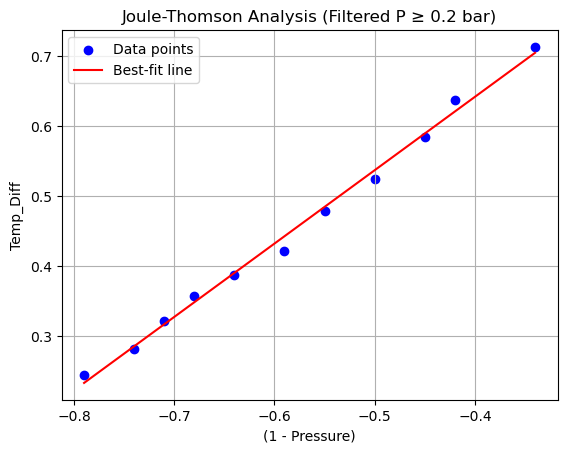

===== Linear Fit Results =====
Slope      : 1.04744 ± 0.03091
Intercept  : 1.06065 ± 0.00000


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
# df = pd.read_csv(csv_file)
# df = pd.read_csv("joule_thomson_data_2_N2.csv") 
df = pd.read_csv("joule_thomson_data_1_CO2.csv")

# Ensure numeric types
df["Pressure"] = pd.to_numeric(df["Pressure"], errors="coerce")
df["Temp_Diff"] = pd.to_numeric(df["Temp_Diff"], errors="coerce")

# Get last row for each pressure
last_rows = df.groupby("Pressure").tail(1)

# Filter out pressures less than 0.5
filtered = last_rows[last_rows["Pressure"] >= 0.2]

# Calculate inverse pressure difference (relative to 1 bar)
P_atm = 1.0  # bar
result = pd.DataFrame({
    "Pressure": filtered["Pressure"],
    "Inv_Pressure": 1 / (P_atm - filtered["Pressure"]),
    "Temp_Diff": filtered["Temp_Diff"]
})

# Sort for clean plotting
result = result.sort_values(by="Inv_Pressure")

# Scatter plot
y = result["Temp_Diff"]
x = result["Pressure"] - 1

plt.scatter(x, y, color='blue', label='Data points')

# Best-fit line
coeffs, cov = np.polyfit(x, y, 1, cov=True)
fit_line = np.poly1d(coeffs)
cov = np.cov(x, y)
# print(cov)
# print(coeffs)

plt.plot(x, fit_line(x), color='red', label='Best-fit line')

plt.ylabel("Temp_Diff")
plt.xlabel("(1 - Pressure)")
plt.title("Joule-Thomson Analysis (Filtered P ≥ 0.2 bar)")
plt.grid(True)
plt.legend()
plt.show()

#
slope = coeffs[0]
intercept = coeffs[1]

# Poor mans uncearintity
slope_unc = np.sqrt(cov[0, 0]**2 + cov[1, 1]**2)
intercept_unc = 0

# Nicely formatted output
print("===== Linear Fit Results =====")
print(f"Slope      : {slope:.5f} ± {slope_unc:.5f}")
print(f"Intercept  : {intercept:.5f} ± {intercept_unc:.5f}")
print("==============================")